In [141]:
# import secrets
# print(secrets.token_hex(32))

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [3]:
with sqlite3.connect("../data/spa.db") as conn:
    df_network_metrics = pd.read_sql_query("SELECT * from network_metrics", conn)
    df_process_metrics = pd.read_sql_query("SELECT * from process_metrics", conn)
    df_system_metrics = pd.read_sql_query("SELECT * from system_metrics", conn)

In [144]:
df_network_metrics.head()

,id,username,timestamp,upload_speed_mb,download_speed_mb,bytes_sent,bytes_received
0,1,Admin,2026-04-25 15:27:05,0.02,0.01,23625595,3195704
1,2,Admin,2026-04-25 15:27:21,0.04,0.05,23873945,4072682
2,3,Admin,2026-04-25 15:27:37,0.01,0.00,25552795,4112728
3,4,Admin,2026-04-25 15:27:53,0.00,0.00,25574260,4122968
4,5,Admin,2026-04-25 15:28:09,0.14,3.16,25787023,7590690


In [145]:
df_process_metrics.head(20)

,id,username,timestamp,process_name,cpu_percent,memory_percent
0,1,Admin,2026-04-25 15:27:05,System Idle Process,0.0,0.000048
1,2,Admin,2026-04-25 15:27:05,System,0.0,0.023064
2,3,Admin,2026-04-25 15:27:05,svchost.exe,0.0,0.009895
3,4,Admin,2026-04-25 15:27:05,,0.0,0.389850
4,5,Admin,2026-04-25 15:27:05,Registry,0.0,0.280645
5,6,Admin,2026-04-25 15:27:05,Code.exe,0.0,0.906361
6,7,Admin,2026-04-25 15:27:05,smss.exe,0.0,0.004502
7,8,Admin,2026-04-25 15:27:05,csrss.exe,0.0,0.019284
8,9,Admin,2026-04-25 15:27:05,conhost.exe,0.0,0.040302
9,10,Admin,2026-04-25 15:27:05,wininit.exe,0.0,0.023160


In [146]:
df_system_metrics.head()

,id,username,timestamp,overall_cpu_load,vm_total_memory,vm_available_memory,vm_used_memory,vm_percent_used,swap_memory_available_total,swap_memory_used,battery_percent
0,1,Admin,2026-04-25 15:27:05,14.350,17.01,4.21,12.81,75.3,12.88,1.29,99.0
1,2,Admin,2026-04-25 15:27:21,27.175,17.01,3.80,13.21,77.7,12.88,1.27,99.0
2,3,Admin,2026-04-25 15:27:37,14.350,17.01,3.56,13.45,79.1,12.88,1.27,99.0
3,4,Admin,2026-04-25 15:27:53,4.150,17.01,3.70,13.31,78.2,12.88,1.27,99.0
4,5,Admin,2026-04-25 15:28:09,16.475,17.01,3.53,13.49,79.3,12.88,1.27,99.0


## EDA

- CPU Load Trend Over Time
- Memory Usage Trend Over Time
- Battery Percentage Trend Over Time
- CPU for Processes
- Memory for Processes
- Network Speed and Usage Over Time

In [8]:
ORANGE = "#ff7f0e"
ACCENT = "#4B9FE1"
TEAL = "#0D9488"
GREEN = "#22C55E"
RED = "#EF4444"

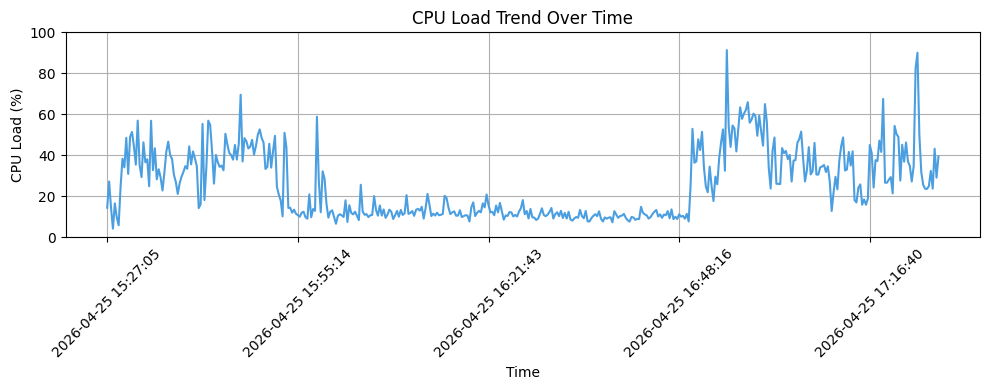

In [148]:
plt.figure(figsize=(10, 4))
plt.plot(df_system_metrics["timestamp"], df_system_metrics["overall_cpu_load"], color=ACCENT)
plt.title("CPU Load Trend Over Time")
plt.xlabel("Time")
plt.ylabel("CPU Load (%)")
plt.ylim(0,100)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show();

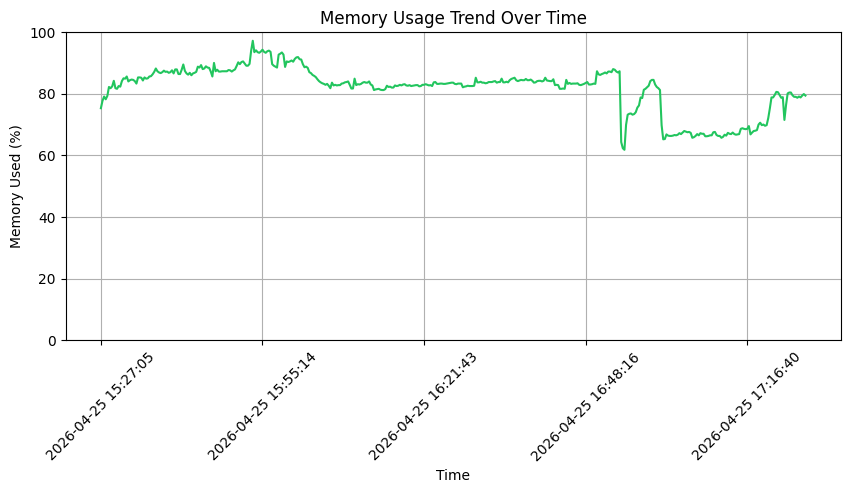

In [149]:
plt.figure(figsize=(10, 4))
plt.plot(df_system_metrics["timestamp"], df_system_metrics["vm_percent_used"], color=GREEN)
plt.title("Memory Usage Trend Over Time")
plt.xlabel("Time")
plt.ylabel("Memory Used (%)")
plt.ylim(0,100)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
plt.xticks(rotation=45)
plt.grid(True)

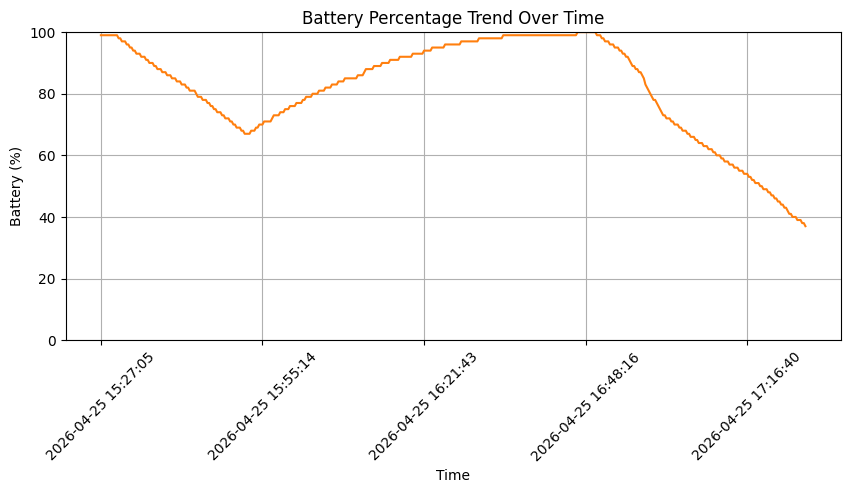

In [150]:
plt.figure(figsize=(10, 4))
plt.plot(df_system_metrics["timestamp"], df_system_metrics["battery_percent"], color="#ff7f0e",)
plt.title("Battery Percentage Trend Over Time")
plt.xlabel("Time")
plt.ylabel("Battery (%)")
plt.ylim(0,100)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
plt.xticks(rotation=45)
plt.grid(True)

In [19]:
process_data = df_process_metrics[pd.to_datetime(df_process_metrics["timestamp"]).dt.day == 25]
process_clean = process_data[process_data['process_name'] != "System Idle Process"]
process_agg = process_clean.groupby(['process_name', 'timestamp']).agg({'cpu_percent': 'sum', 'memory_percent': 'sum'}).reset_index()
# Get top 10 CPU-consuming processes
top10_cpu_processes = process_agg.groupby('process_name')['cpu_percent'].sum().sort_values(ascending=False).head(10).index
agg_top10 = process_agg[process_agg['process_name'].isin(top10_cpu_processes)]
cpu_total = agg_top10.groupby('process_name')['cpu_percent'].sum()
memory_total = agg_top10.groupby('process_name')['memory_percent'].sum()
# Normalize to 100%
cpu_total_norm = cpu_total / cpu_total.sum() * 100
memory_total_norm = memory_total / memory_total.sum() * 100

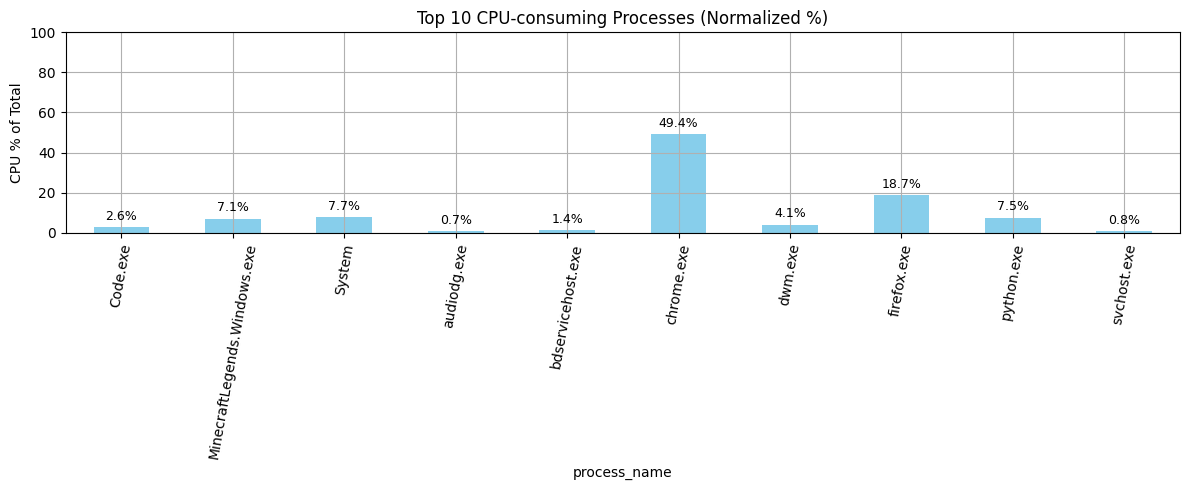

In [152]:
plt.figure(figsize=(12,5))
ax = cpu_total_norm.plot(kind='bar', color='skyblue')
plt.title('Top 10 CPU-consuming Processes (Normalized %)')
plt.ylabel('CPU % of Total')
plt.ylim(0,100)
plt.xticks(rotation=80)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.grid(True)

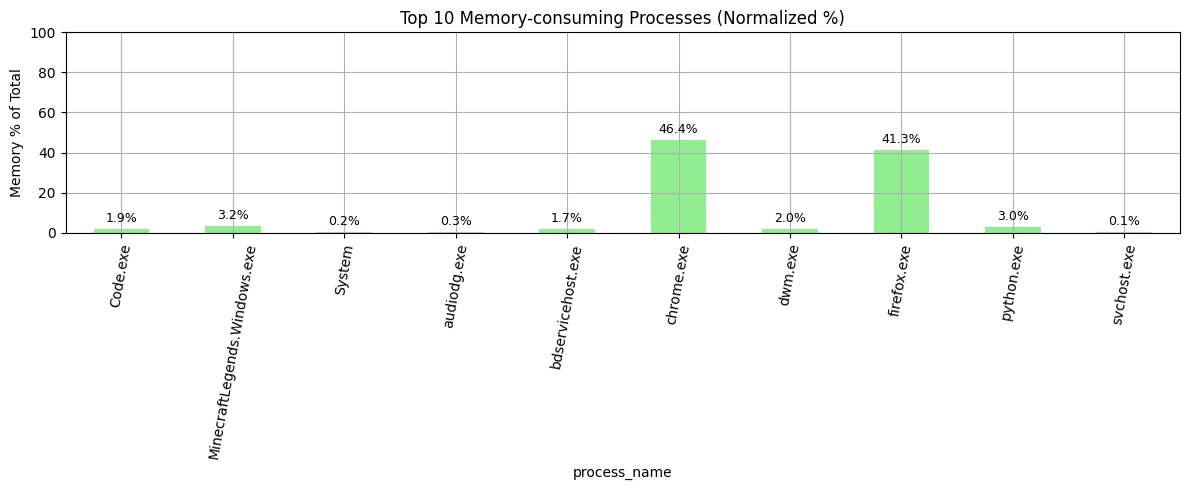

In [153]:
plt.figure(figsize=(12,5))
ax = memory_total_norm.plot(kind='bar', color='lightgreen')
plt.title('Top 10 Memory-consuming Processes (Normalized %)')
plt.ylabel('Memory % of Total')
plt.xticks(rotation=80)
plt.ylim(0,100)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.grid(True)

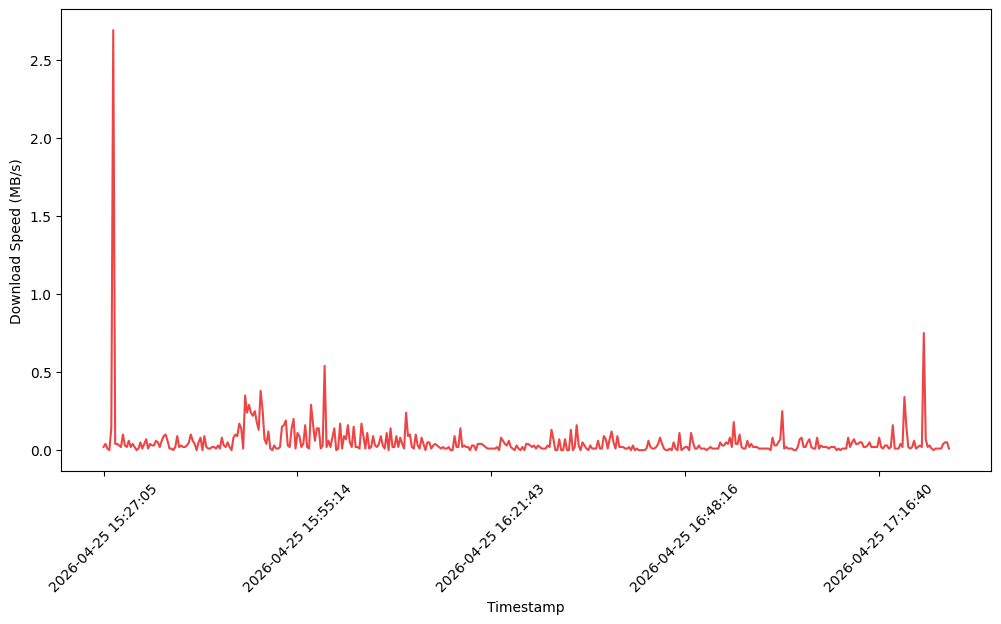

In [154]:
plt.subplots(figsize=(12,6))
plt.plot(df_network_metrics['timestamp'], df_network_metrics['upload_speed_mb'], color=RED)
plt.xlabel('Timestamp')
plt.ylabel('Download Speed (MB/s)')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
plt.xticks(rotation=45);

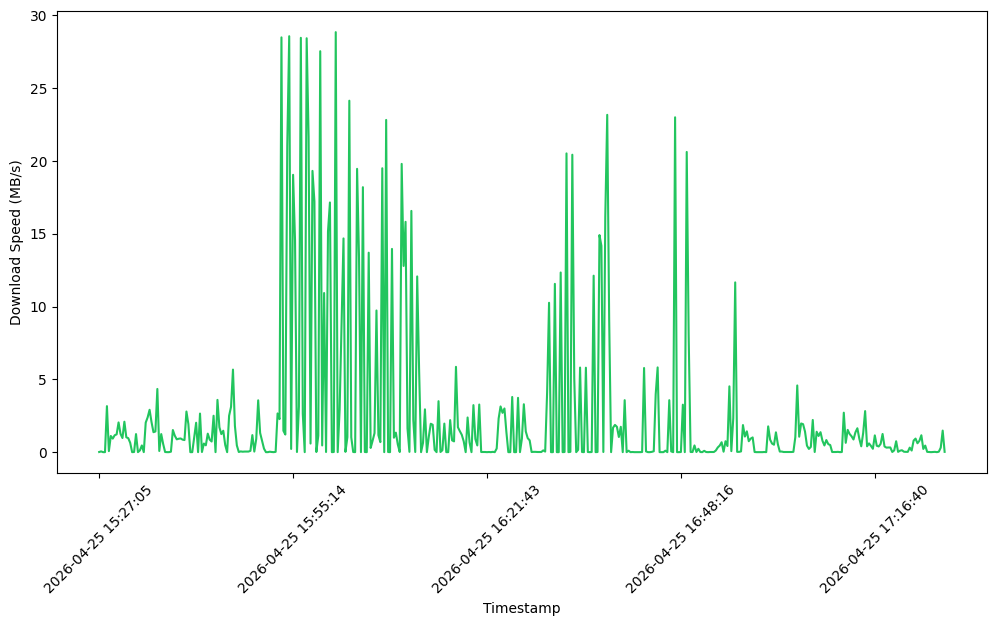

In [155]:
plt.subplots(figsize=(12,6))
plt.plot(df_network_metrics['timestamp'], df_network_metrics['download_speed_mb'], color=GREEN)
plt.xlabel('Timestamp')
plt.ylabel('Download Speed (MB/s)')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
plt.xticks(rotation=45);

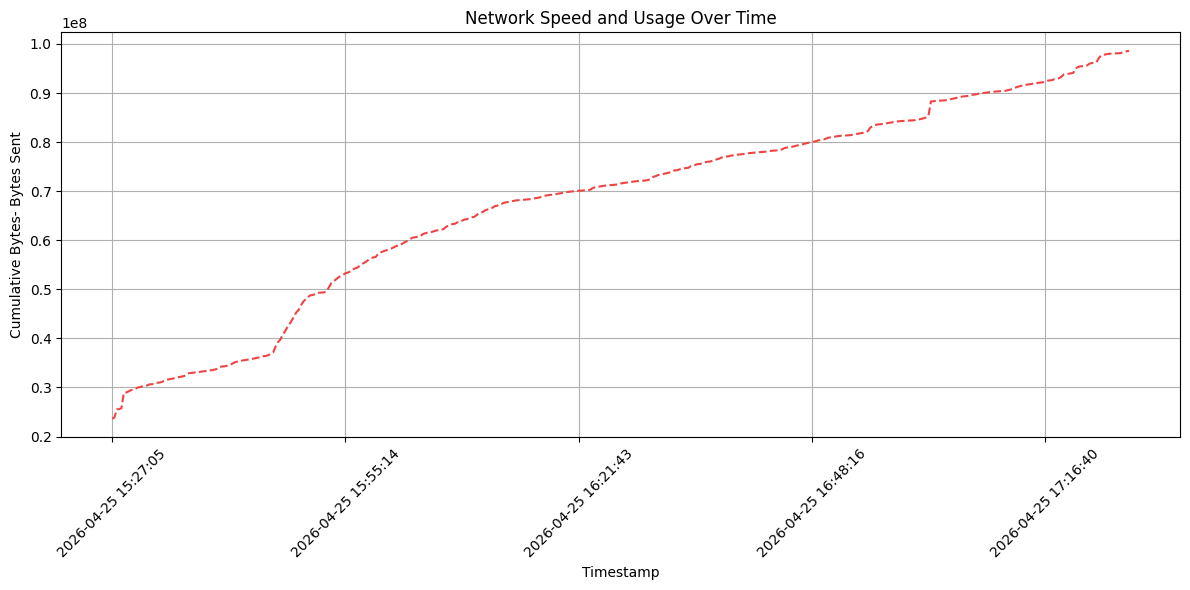

In [156]:
plt.subplots(figsize=(12,6))
plt.plot(df_network_metrics['timestamp'], df_network_metrics['bytes_sent'],  color=RED, linestyle='--')
plt.xlabel("Timestamp")
plt.ylabel('Cumulative Bytes- Bytes Sent')
plt.title('Network Speed and Usage Over Time')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
plt.grid()
plt.tight_layout()

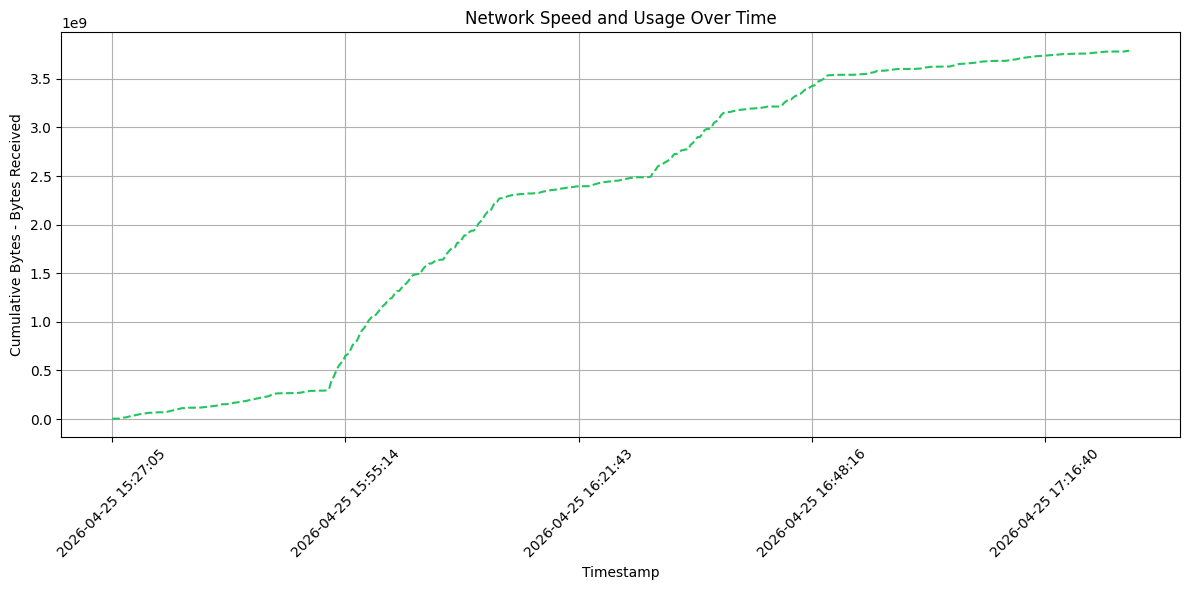

In [157]:
plt.subplots(figsize=(12,6))
plt.plot(df_network_metrics['timestamp'], df_network_metrics['bytes_received'],  color=GREEN, linestyle='--')
plt.xlabel("Timestamp")
plt.ylabel('Cumulative Bytes - Bytes Received')
plt.title('Network Speed and Usage Over Time')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
plt.grid()
plt.tight_layout()

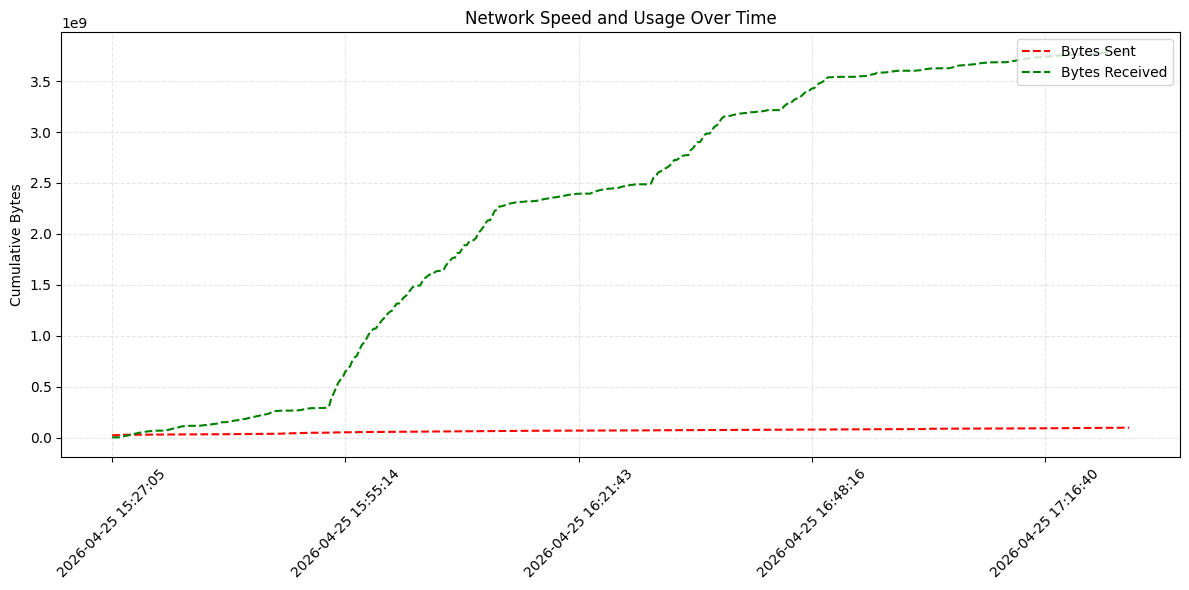

In [158]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(df_network_metrics['timestamp'], df_network_metrics['bytes_sent'], label='Bytes Sent', color='red', linestyle='--')
ax.plot(df_network_metrics['timestamp'], df_network_metrics['bytes_received'], label='Bytes Received', color='green', linestyle='--')
ax.set_ylabel('Cumulative Bytes')
ax.legend(loc='upper right')
plt.title('Network Speed and Usage Over Time')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

## ML - Anomaly Detection
### System Anomaly

In [159]:
df = df_system_metrics.copy()
df['anomaly'] = 0
features = ["overall_cpu_load", "vm_percent_used"]

In [160]:
df.head()

,id,username,timestamp,overall_cpu_load,vm_total_memory,vm_available_memory,vm_used_memory,vm_percent_used,swap_memory_available_total,swap_memory_used,battery_percent,anomaly
0,1,Admin,2026-04-25 15:27:05,14.350,17.01,4.21,12.81,75.3,12.88,1.29,99.0,0
1,2,Admin,2026-04-25 15:27:21,27.175,17.01,3.80,13.21,77.7,12.88,1.27,99.0,0
2,3,Admin,2026-04-25 15:27:37,14.350,17.01,3.56,13.45,79.1,12.88,1.27,99.0,0
3,4,Admin,2026-04-25 15:27:53,4.150,17.01,3.70,13.31,78.2,12.88,1.27,99.0,0
4,5,Admin,2026-04-25 15:28:09,16.475,17.01,3.53,13.49,79.3,12.88,1.27,99.0,0


In [161]:
valid = df[features].dropna()

In [162]:
scaler = StandardScaler()
X = scaler.fit_transform(valid)
clf = IsolationForest(contamination=0.05, random_state=42)
# -1 = anomaly, 1 = normal
preds = clf.fit_predict(X)
df.loc[valid.index, "anomaly"] = (preds == -1).astype(int)
n = df["anomaly"].sum()

In [163]:
n/len(df)

np.float64(0.05034324942791762)

In [164]:
n

np.int64(22)

In [165]:
df[df['anomaly'] == 1].head(10)

,id,username,timestamp,overall_cpu_load,vm_total_memory,vm_available_memory,vm_used_memory,vm_percent_used,swap_memory_available_total,swap_memory_used,battery_percent,anomaly
3,4,Admin,2026-04-25 15:27:53,4.1500,17.01,3.70,13.31,78.2,12.88,1.27,99.0,1
70,71,Admin,2026-04-25 15:46:48,69.5500,17.01,1.70,15.31,90.0,12.88,1.66,75.0,1
93,94,Admin,2026-04-25 15:53:22,50.9500,17.01,1.02,15.99,94.0,12.88,1.78,68.0,1
94,95,Admin,2026-04-25 15:53:38,43.8250,17.01,0.48,16.53,97.2,12.88,1.78,68.0,1
96,97,Admin,2026-04-25 15:54:10,14.3750,17.01,1.00,16.01,94.1,12.88,1.78,69.0,1
104,105,Admin,2026-04-25 15:56:17,9.7000,17.01,1.02,16.00,94.0,12.88,1.78,71.0,1
110,111,Admin,2026-04-25 15:57:52,58.7750,17.01,1.24,15.77,92.7,12.88,2.03,73.0,1
111,112,Admin,2026-04-25 15:58:08,27.3875,17.01,1.19,15.82,93.0,12.88,2.06,74.0,1
113,114,Admin,2026-04-25 15:58:40,32.1500,17.01,1.25,15.77,92.7,12.88,2.03,74.0,1
120,121,Admin,2026-04-25 16:00:31,6.5375,17.01,1.49,15.53,91.3,12.88,2.04,76.0,1


### Network Anomaly

In [166]:
df = df_network_metrics.copy()
df['net_anomaly'] = False

In [167]:
df.head()

,id,username,timestamp,upload_speed_mb,download_speed_mb,bytes_sent,bytes_received,net_anomaly
0,1,Admin,2026-04-25 15:27:05,0.02,0.01,23625595,3195704,False
1,2,Admin,2026-04-25 15:27:21,0.04,0.05,23873945,4072682,False
2,3,Admin,2026-04-25 15:27:37,0.01,0.00,25552795,4112728,False
3,4,Admin,2026-04-25 15:27:53,0.00,0.00,25574260,4122968,False
4,5,Admin,2026-04-25 15:28:09,0.14,3.16,25787023,7590690,False


In [168]:
for col in ("upload_speed_mb", "download_speed_mb"):
        if col in df.columns:
            m, s = df[col].mean(), df[col].std() or 1
            df["net_anomaly"] |= (df[col] > m + 2 * s)

In [169]:
df[df["net_anomaly"] == True].head(10)

,id,username,timestamp,upload_speed_mb,download_speed_mb,bytes_sent,bytes_received,net_anomaly
5,6,Admin,2026-04-25 15:28:25,2.69,0.07,28893814,15164960,True
73,74,Admin,2026-04-25 15:47:40,0.35,0.05,40600459,265286203,True
81,82,Admin,2026-04-25 15:49:57,0.38,0.91,46777915,272488138,True
94,95,Admin,2026-04-25 15:53:38,0.19,28.49,51313806,394002787,True
97,98,Admin,2026-04-25 15:54:26,0.14,21.05,52441476,541393847,True
98,99,Admin,2026-04-25 15:54:42,0.20,28.57,52705005,573334921,True
100,101,Admin,2026-04-25 15:55:14,0.11,19.05,53277210,651864375,True
101,102,Admin,2026-04-25 15:55:30,0.09,14.56,53392478,667150090,True
104,105,Admin,2026-04-25 15:56:17,0.16,28.46,54237965,787577200,True
107,108,Admin,2026-04-25 15:57:05,0.29,28.43,55150581,909585733,True


### Process Anomaly

In [170]:
df = df_process_metrics.copy()

In [171]:
agg = (df.groupby("process_name").agg(avg_cpu=("cpu_percent", "mean"), 
                                      avg_mem=("memory_percent", "mean"), 
                                      count=("cpu_percent", "count")).reset_index())
agg = agg[agg["process_name"] != "System Idle Process"]

In [172]:
agg.head()

,process_name,avg_cpu,avg_mem,count
0,,0.000000,0.389850,1
1,AdobeARM.exe,41.250000,1.077536,2
2,Code.exe,23.122973,1.862801,74
3,DB Browser for SQLite.exe,37.400000,0.422232,1
4,DiskSnapshot.exe,64.500000,1.799817,2


In [173]:
mean_cpu = agg["avg_cpu"].mean()
std_cpu  = agg["avg_cpu"].std() or 1
agg["cpu_zscore"] = ((agg["avg_cpu"] - mean_cpu) / std_cpu).round(2)
agg["flagged"] = agg["cpu_zscore"] > 2.0 

In [174]:
agg.sort_values("avg_cpu", ascending=False).head(10).round(2).reset_index(drop=True)

,process_name,avg_cpu,avg_mem,count,cpu_zscore,flagged
0,MinecraftLegends.Windows.exe,210.48,10.93,22,5.34,True
1,DiskSnapshot.exe,64.50,1.80,2,1.25,False
2,Taskmgr.exe,49.80,1.11,1,0.84,False
3,AdobeARM.exe,41.25,1.08,2,0.60,False
4,DB Browser for SQLite.exe,37.40,0.42,1,0.50,False
5,Code.exe,23.12,1.86,74,0.10,False
6,chrome.exe,22.69,2.43,1420,0.08,False
7,Telegram.exe,22.01,3.16,15,0.07,False
8,msedge.exe,19.24,1.12,8,-0.01,False
9,bdservicehost.exe,18.04,2.55,50,-0.05,False


### Interactive Graphs 

In [1]:
import plotly.graph_objects as go
import plotly.express as px

In [6]:
fig = go.Figure()
fig.add_trace(
go.Scatter(x=df_system_metrics["timestamp"], y=df_system_metrics["overall_cpu_load"], name="CPU %", line=dict(color=ACCENT)))
fig.update_yaxes(range=[0, 100])
fig.update_layout(title="CPU Load", height=300)

In [ ]:
fig2 = px.line(df_system_metrics, x="timestamp", y="vm_percent_used", title="RAM Usage %", color_discrete_sequence=[GREEN])
fig2.update_yaxes(range=[0, 100])
fig2.update_layout(height=250)

In [9]:
fig3 = px.line(df_system_metrics, x="timestamp", y="battery_percent", title="Battery %", color_discrete_sequence=[ORANGE])
fig3.update_yaxes(range=[0, 100])
fig3.update_layout(height=250)

In [30]:
fig = go.Figure()
fig.add_trace(go.Bar(x=cpu_total_norm.index, y=cpu_total_norm.values, marker_color='skyblue', text=[f"{v:.2f} %" for v in cpu_total_norm.values],))

fig.update_layout(title='Top 10 CPU-consuming Processes (Normalized %)', xaxis_title='', yaxis_title='CPU % of Total', xaxis=dict(tickangle=80), template='plotly_white',height=500,width=900)
fig.update_yaxes(showgrid=True)

fig.show()

In [32]:
cpu_total_norm.values.sum()

np.float64(100.00000000000003)

In [35]:
fig = go.Figure()
fig.add_trace(go.Bar(x=memory_total_norm.index, y=memory_total_norm.values, marker_color='lightgreen'))

fig.update_layout(title='Top 10 Memory-consuming Processes (Normalized %)', xaxis_title='', yaxis_title='Memory % of Total', xaxis=dict(tickangle=80), template='plotly_white',height=500,width=900)
fig.update_yaxes(showgrid=True)

fig.show()

In [ ]:
fig = go.Figure()
fig.add_trace(
go.Scatter(x=df_network_metrics["timestamp"], y=df_network_metrics["download_speed_mb"], name="CPU %", line=dict(color=ACCENT)))
fig.update_layout(title="Download Speed (MB/s)", height=300)

In [40]:
fig = go.Figure()
fig.add_trace(
go.Scatter(x=df_network_metrics["timestamp"], y=df_network_metrics["upload_speed_mb"], name="CPU %", line=dict(color=RED)))
fig.update_layout(title="Upload Speed (MB/s)", height=300)